# EDA

In [2]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 4, Finished, Available, Finished, False)

In [3]:
%run ./tariff_plot

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 5, Finished, Available, Finished, True)

In [15]:
%run ./consumption_plot

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 17, Finished, Available, Finished, True)

In [5]:
%run ./peak_plot

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 7, Finished, Available, Finished, True)

## import existing data

In [6]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
print(month_result.shape)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 8, Finished, Available, Finished, False)

(4538578, 17)


In [ ]:
month_result

In [ ]:
month_result[month_result["price"] == "high"]

In [61]:
# teriff data
tariff_df = (
    spark.read.format("csv")
    .option("header", "true")
    .option("sep", ";")
    .load("abfss://902275ba-e699-4505-9532-1f979686157f@onelake.dfs.fabric.microsoft.com/cd3a1398-1ea6-4b6b-a5c7-68d125bf9ac0/Files/Anläggningar med tidsindelad from 1 dec 2025.csv")
)
tariff_df.createOrReplaceTempView("tariff_df")
# display(tariff_df)
tariff_data = tariff_df.toPandas()

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 63, Finished, Available, Finished, False)

In [62]:
hourly_result= pd.read_parquet("/lakehouse/default/Files/hour_data")
print(hourly_result.shape)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 64, Finished, Available, Finished, False)

(3088186, 9)


In [63]:
weekly_result= pd.read_parquet("/lakehouse/default/Files/weekday_data")
print(weekly_result.shape)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 65, Finished, Available, Finished, False)

(961894, 9)


## Start EDA - Tariff

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 66, Finished, Available, Finished, False)

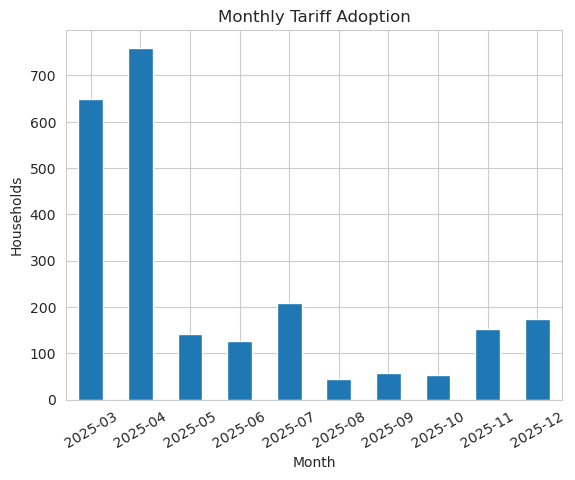

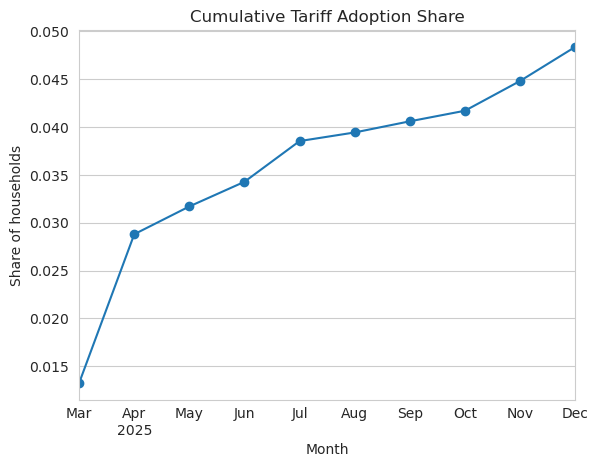

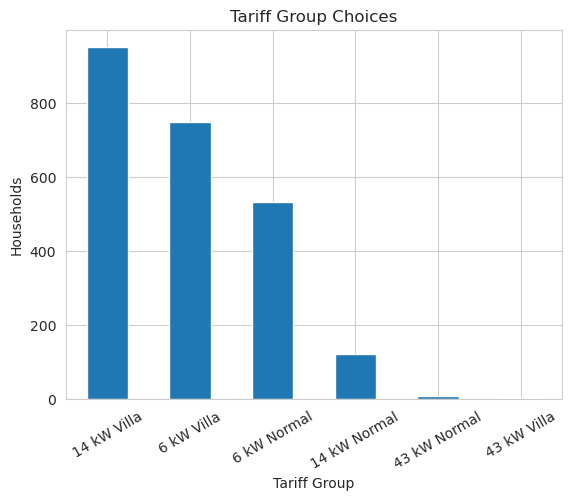

<Figure size 640x480 with 0 Axes>

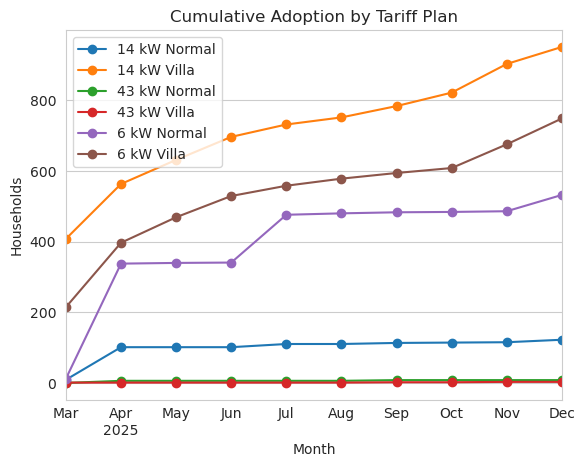

In [64]:
plot_monthly_adoption(tariff_data)
plt.show()

plot_monthly_share(tariff_data, total_households=48930)
plt.show()

plot_tariff_group_counts(tariff_data)
plt.show()

plot_tariff_group_cumulative(tariff_data)
plt.show()

## Electricity data

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 67, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Monthly Peak Consumption (Control group: Never adopters)'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>

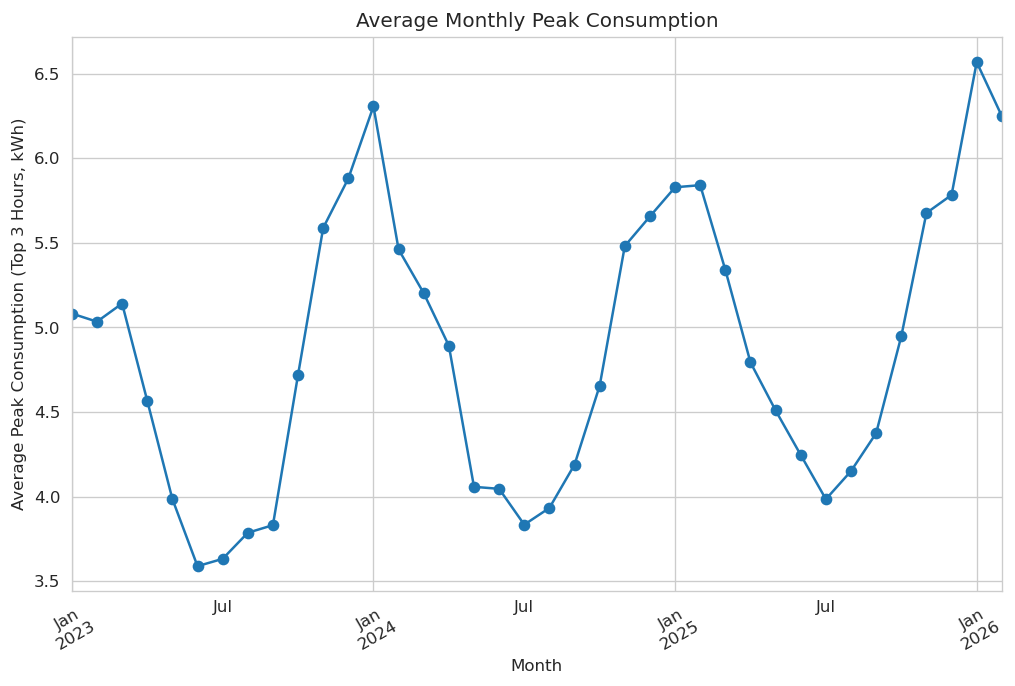

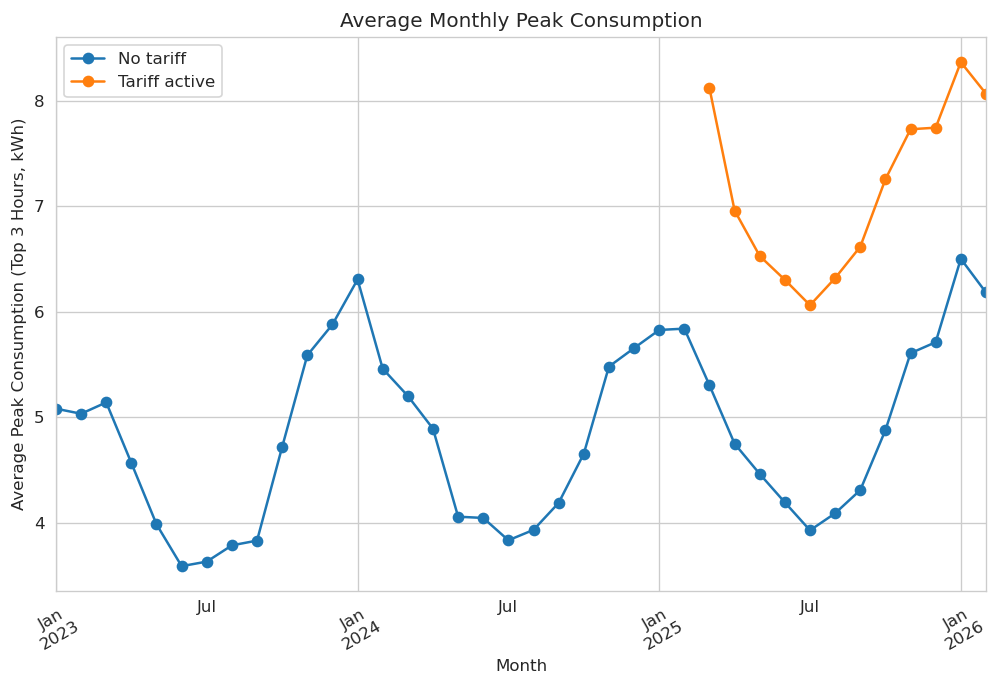

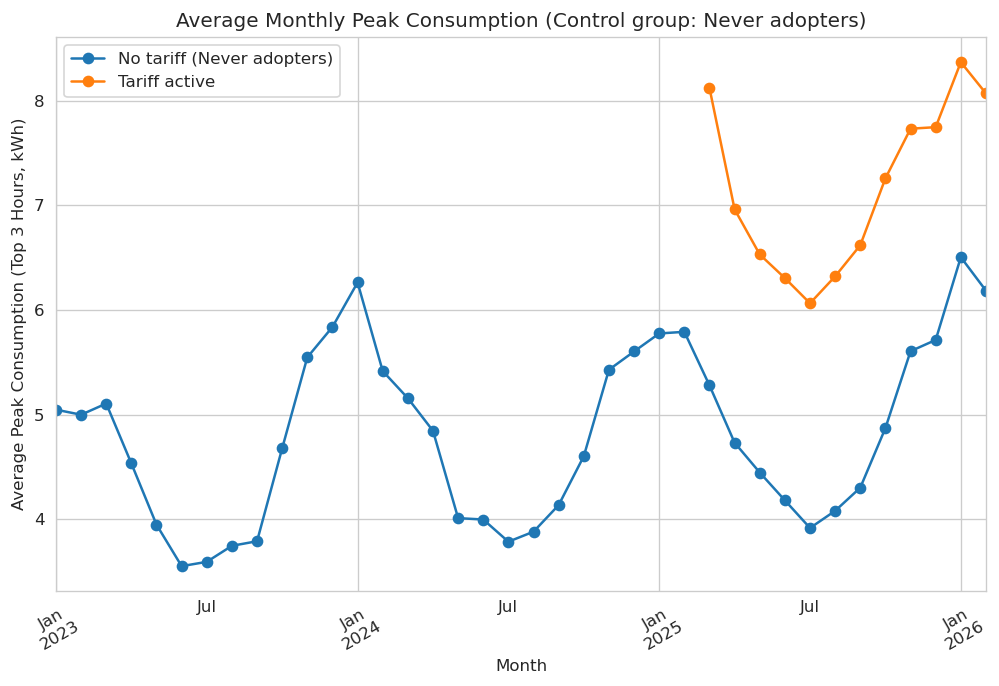

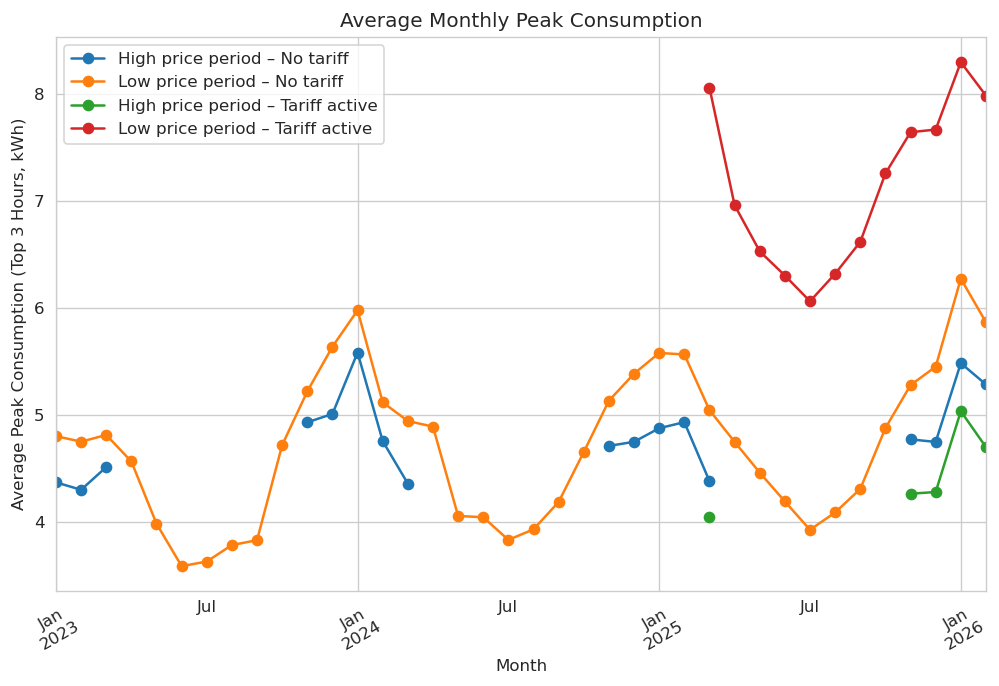

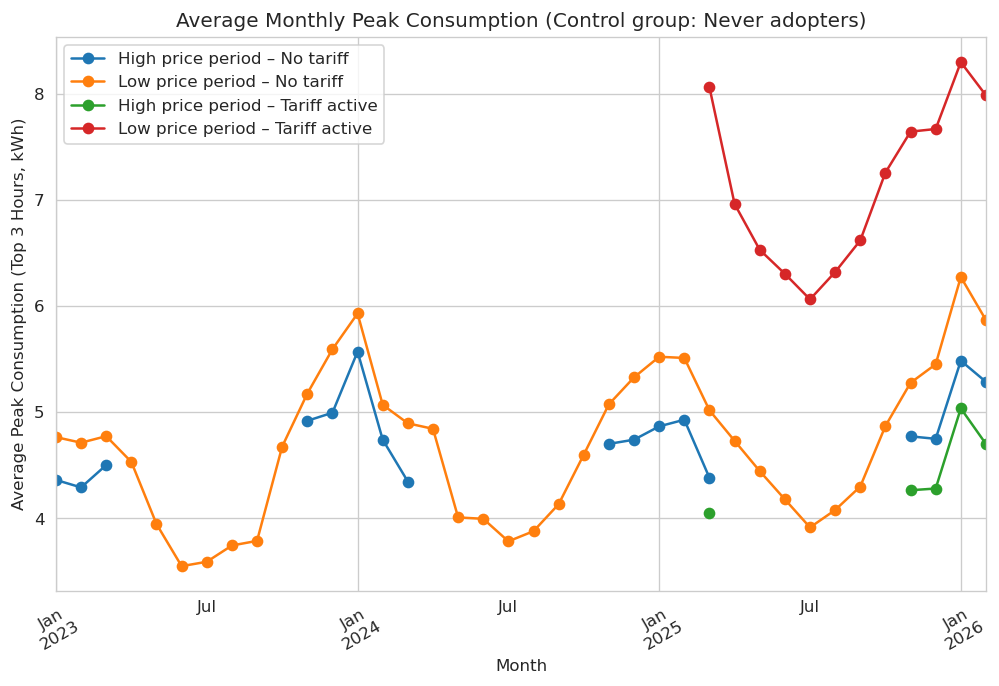

In [65]:
# month
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 68, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Hourly Consumption Profile (Control group: Never adopters)'}, xlabel='Hour of Day', ylabel='Average Electricity Consumption (kWh)'>

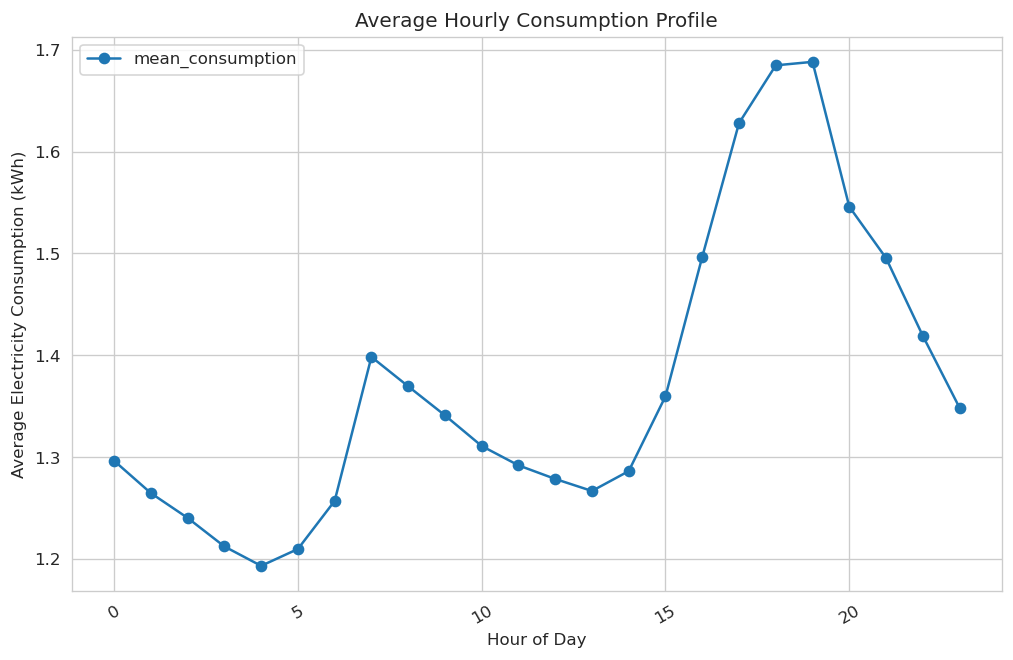

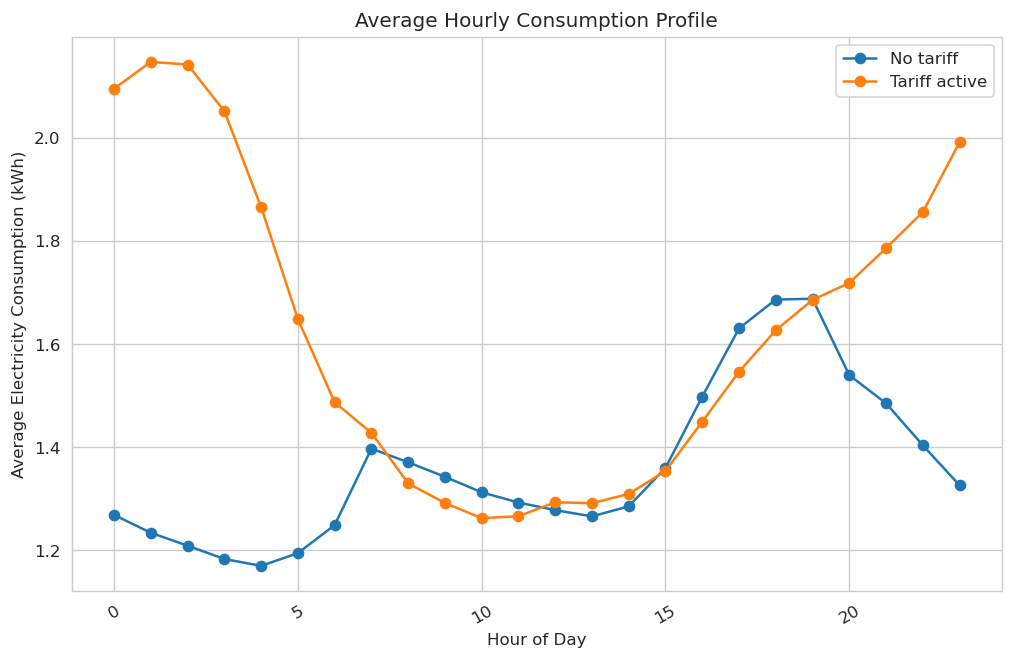

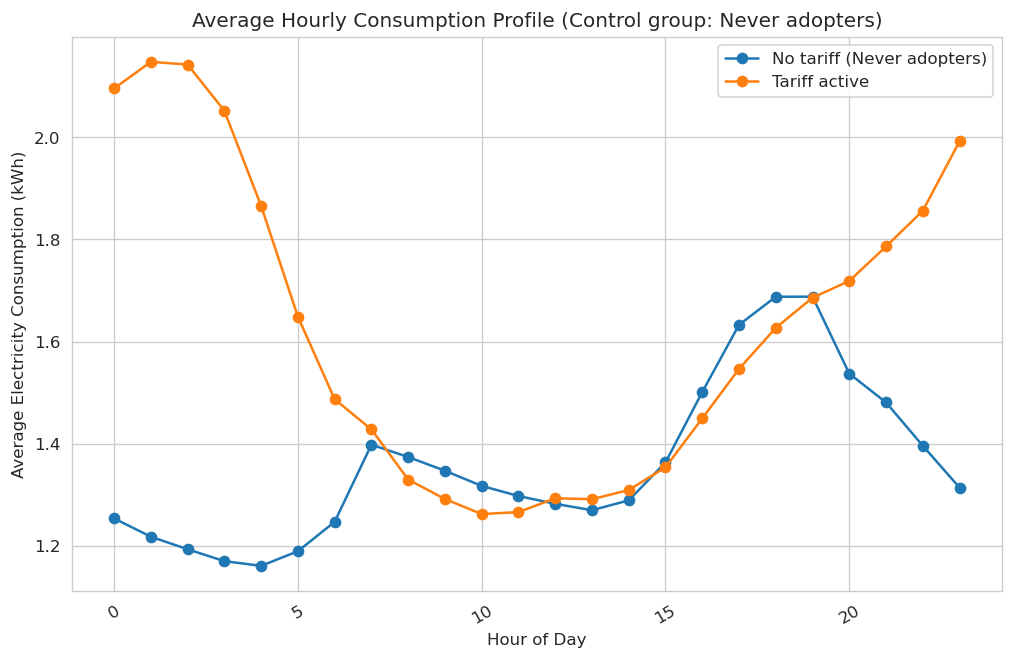

In [66]:
# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
)

hour_result.groupby("tariff_active").size()


# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"]
)

# hour
plot_consumption(
    hourly_result,
    group_by="hour",
    value_col="mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 69, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Consumption by Day of Week'}, xlabel='Day of Week', ylabel='Average Electricity Consumption (kWh)'>

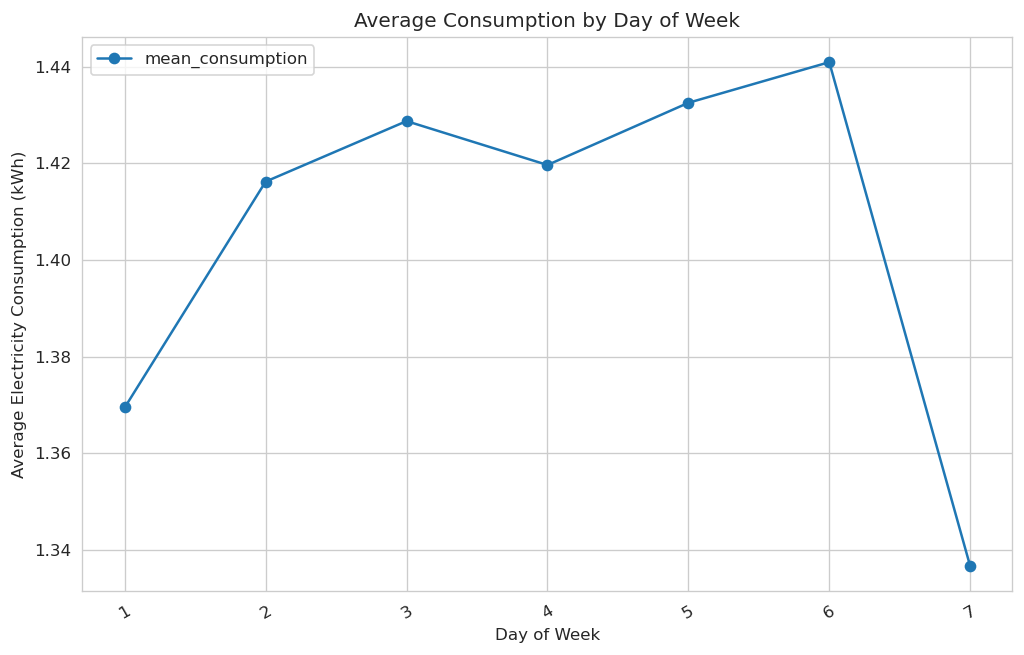

In [67]:
# weekend, week
plot_consumption(
    weekly_result,
    group_by="weekday",
    value_col="mean_consumption",
)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 70, Finished, Available, Finished, False)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

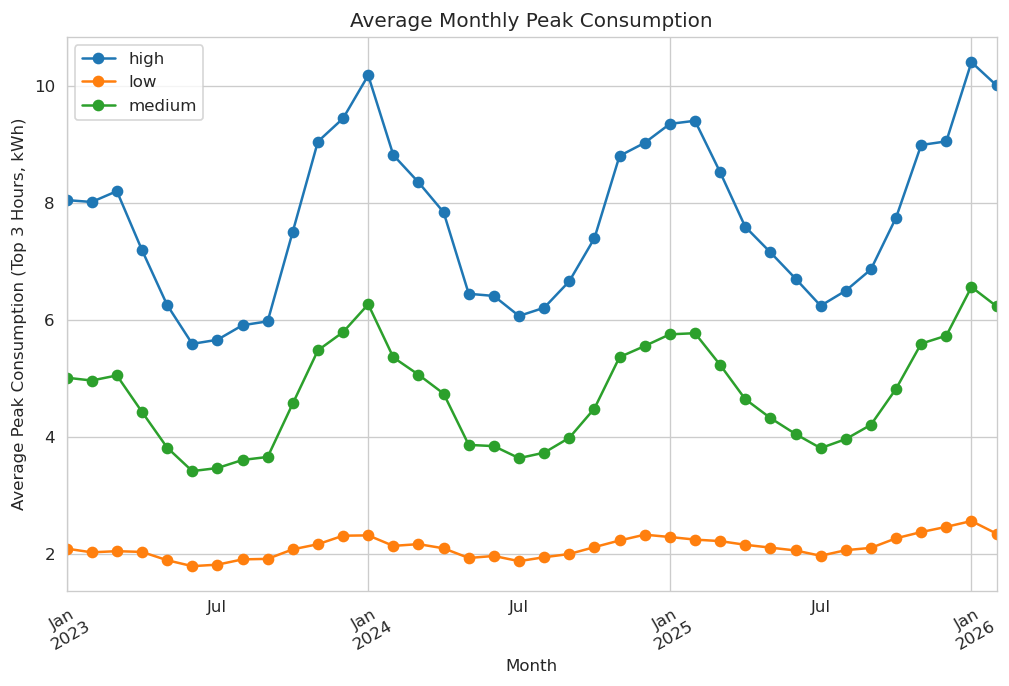

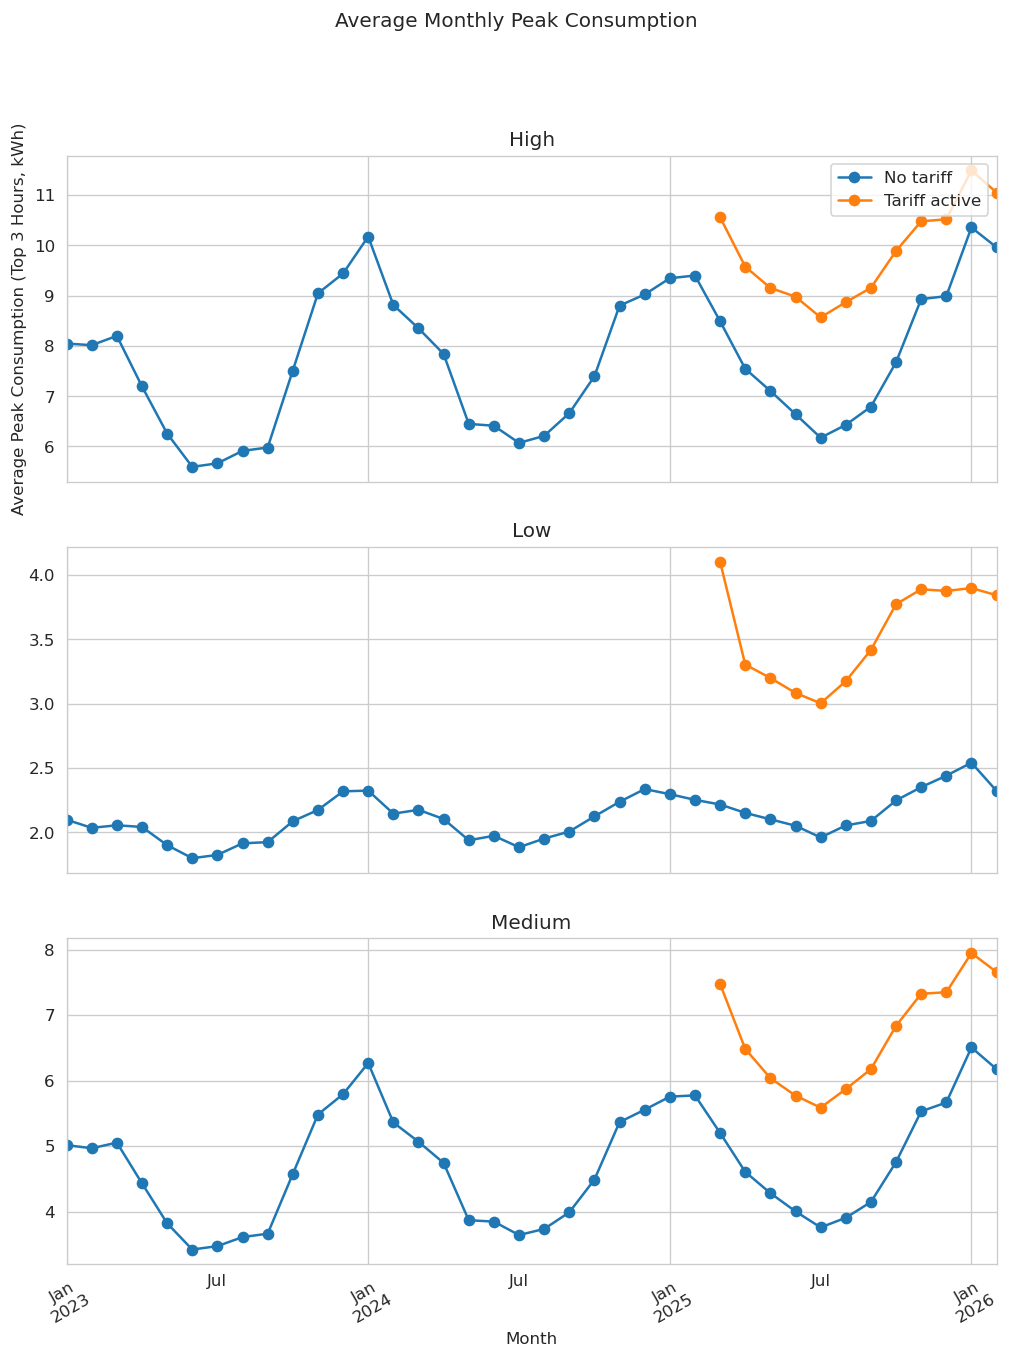

In [68]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

StatementMeta(, 3fe09fbe-b390-4476-8111-89d7aefeb4e3, 71, Finished, Available, Finished, False)

array([<Axes: title={'center': 'High'}, xlabel='Month', ylabel='Average Peak Consumption (Top 3 Hours, kWh)'>,
       <Axes: title={'center': 'Low'}, xlabel='Month'>,
       <Axes: title={'center': 'Medium'}, xlabel='Month'>], dtype=object)

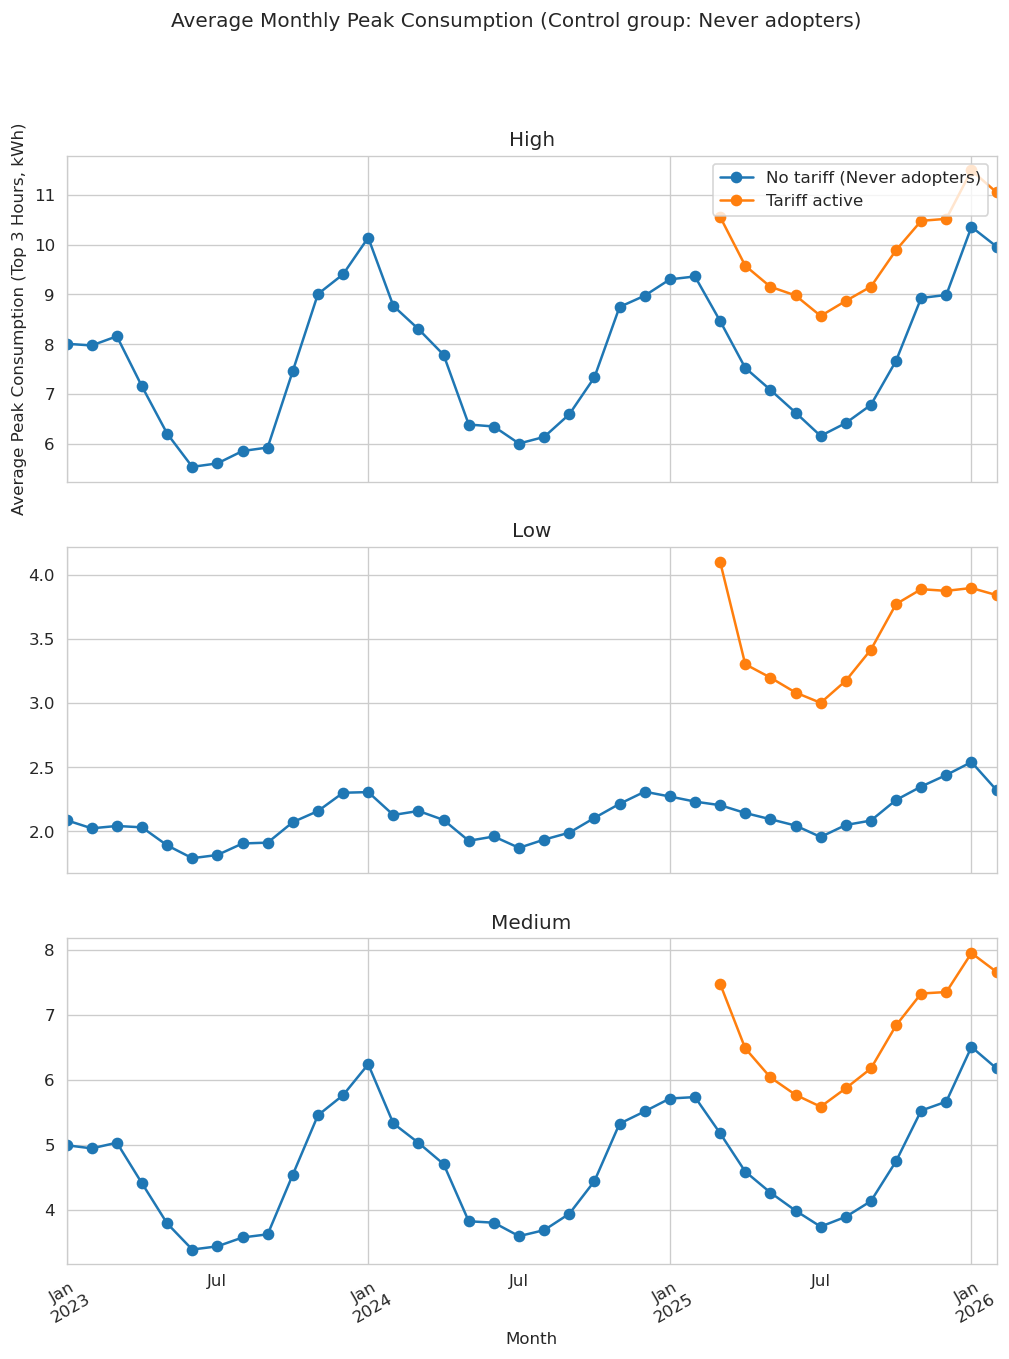

In [69]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 9, Finished, Available, Finished, False)

<Axes: title={'center': 'Tariff Adoption by Household Usage Group'}, xlabel='Household Usage Group', ylabel='Share Choosing Tariff'>

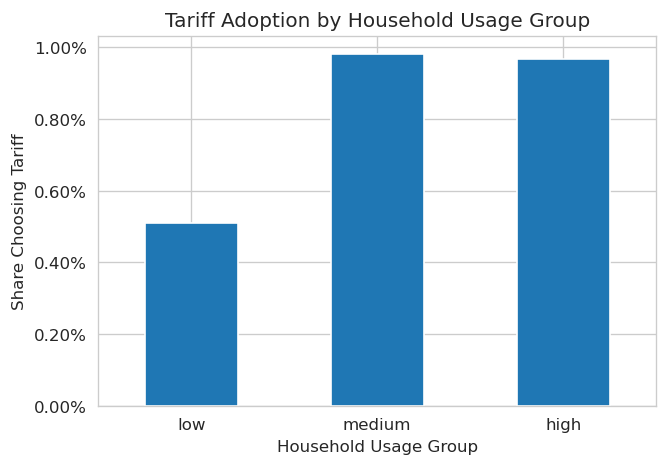

In [7]:
plot_tariff_adoption_by_usage(
    month_result[month_result["price"] == "all"],
    figsize=(6, 4)
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 10, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

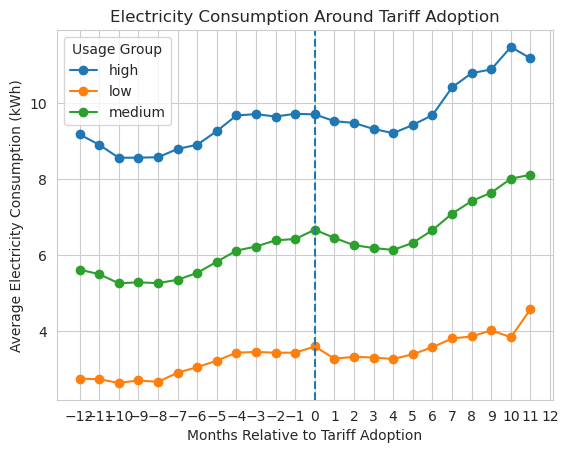

In [8]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 11, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

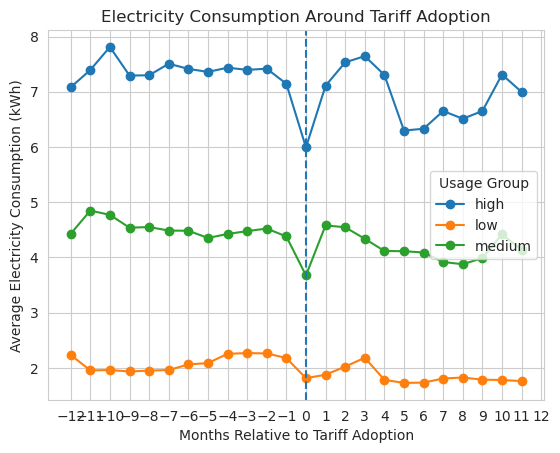

In [9]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 12, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

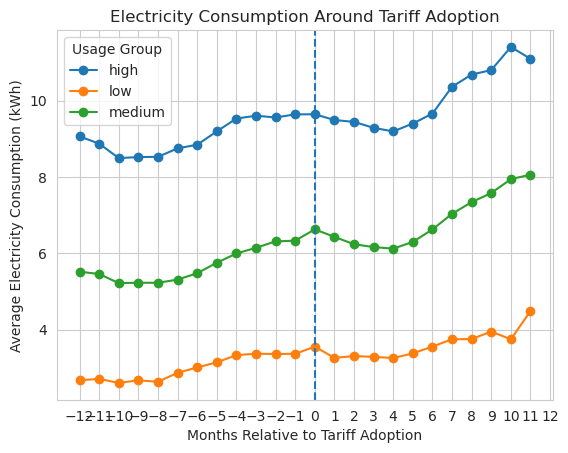

In [10]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 13, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

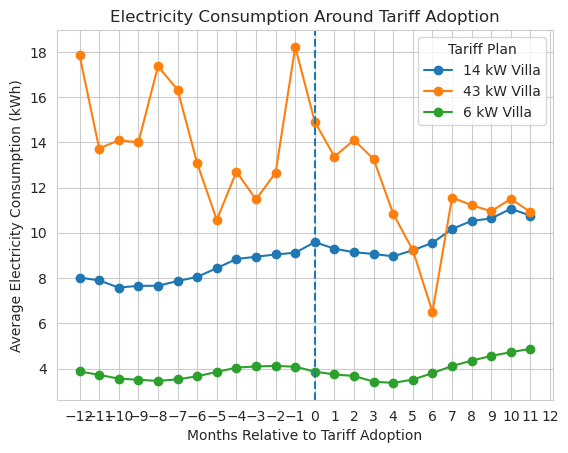

In [11]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 14, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

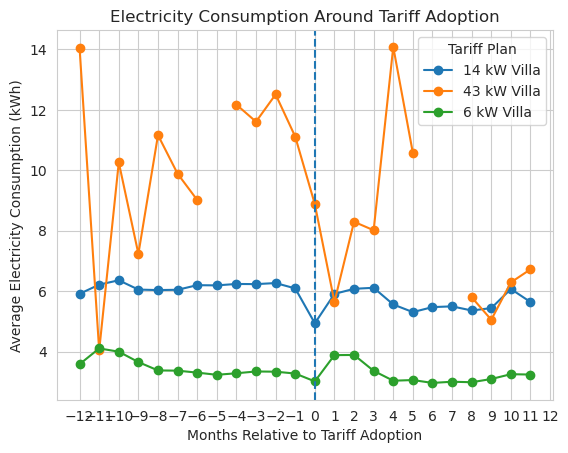

In [12]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 15, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

<Figure size 640x480 with 0 Axes>

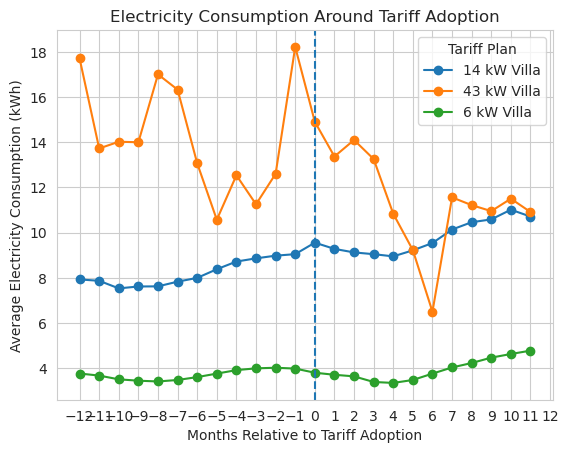

In [13]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 18, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

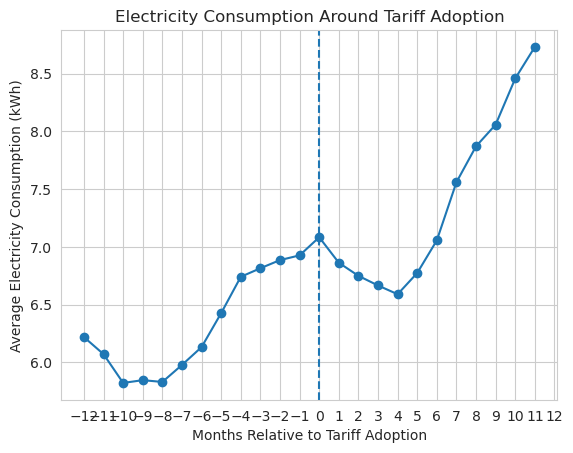

In [16]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 19, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

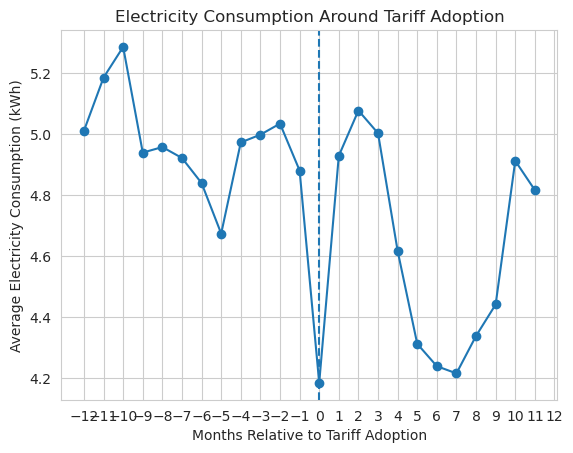

In [17]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 17167595-dcbd-4b4e-b7b7-7e4956d3d6a8, 20, Finished, Available, Finished, False)

<Axes: title={'center': 'Electricity Consumption Around Tariff Adoption'}, xlabel='Months Relative to Tariff Adoption', ylabel='Average Electricity Consumption (kWh)'>

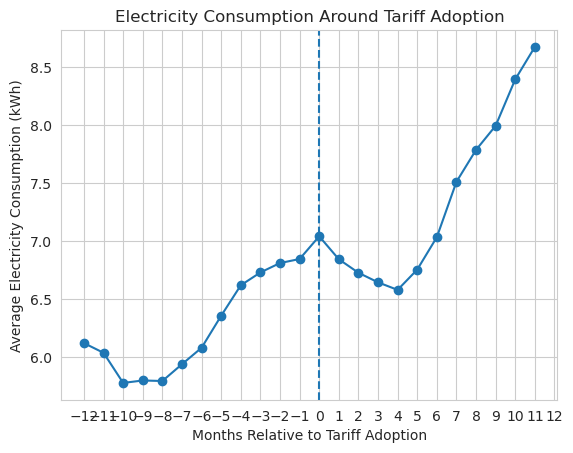

In [18]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, a1218c3f-f2d3-49be-8874-e8bb978f4cb6, 15, Finished, Available, Finished, False)

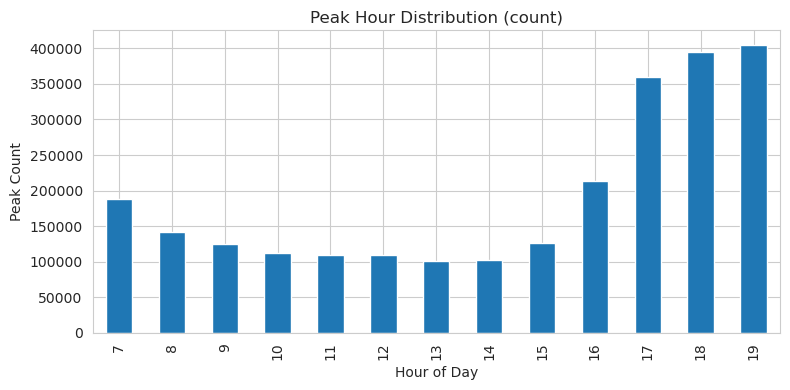

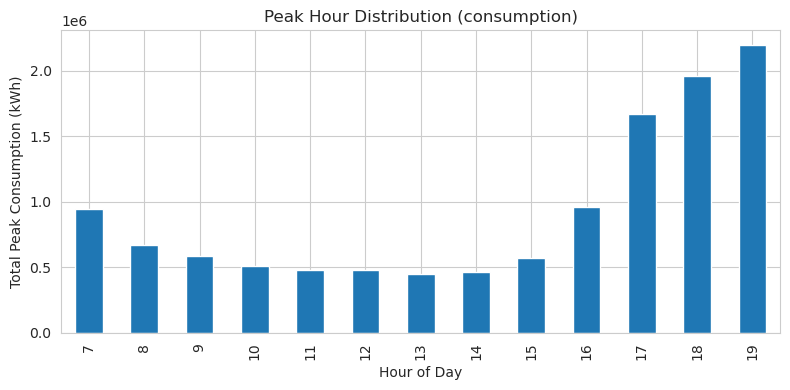

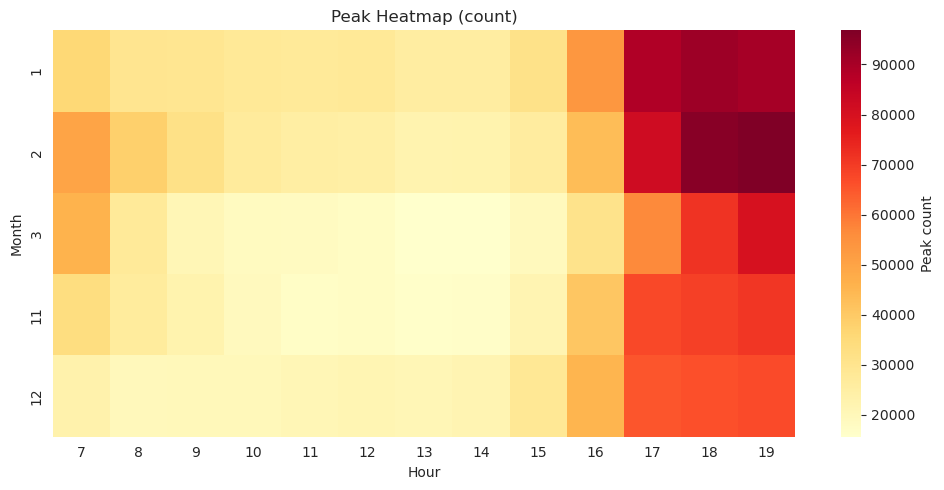

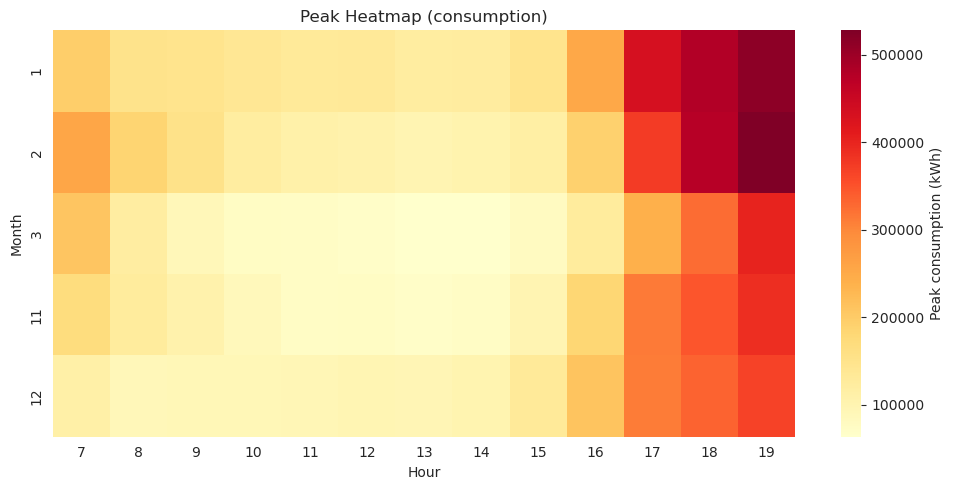

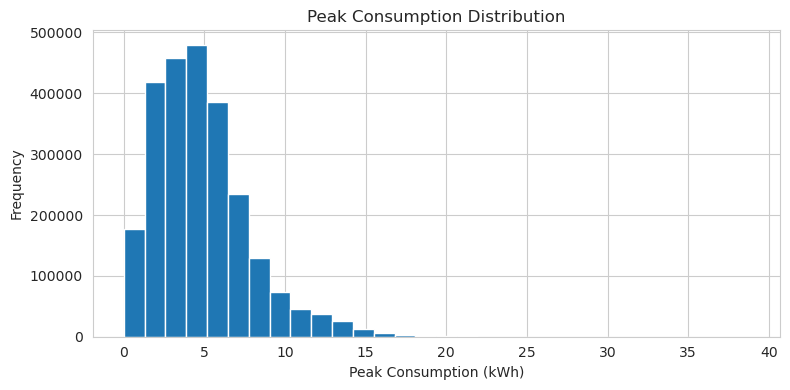

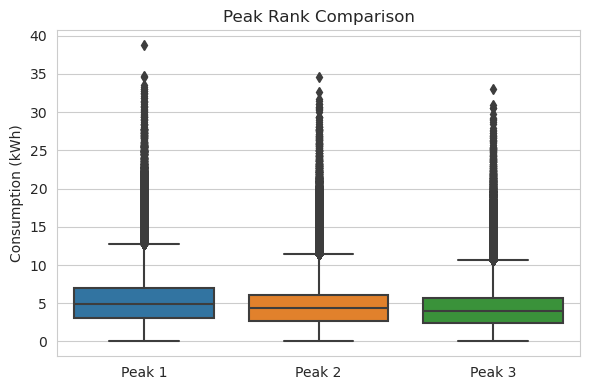

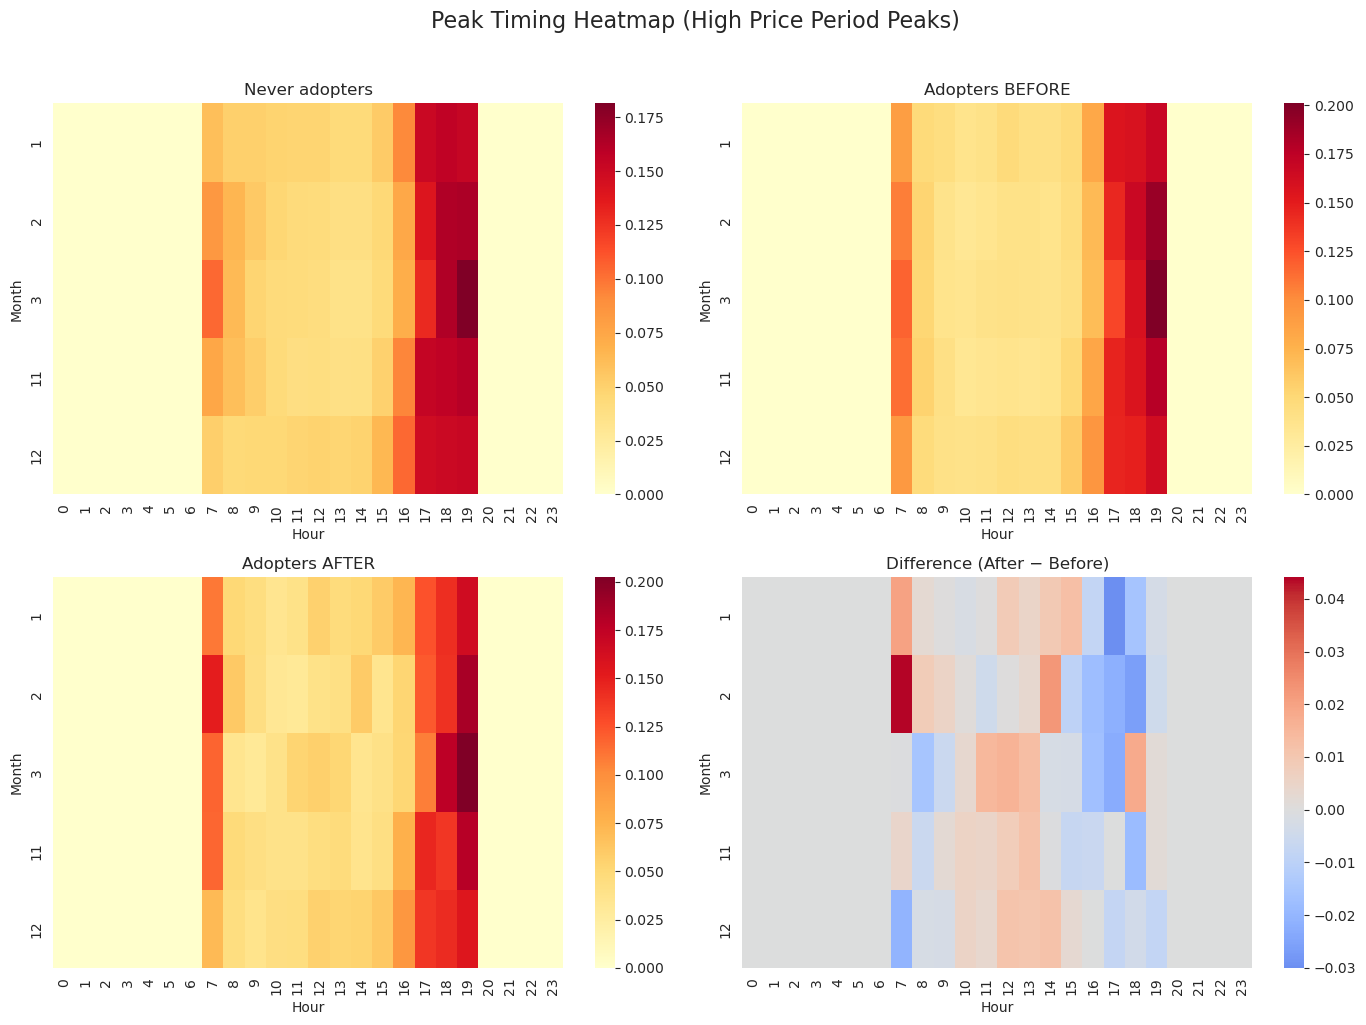

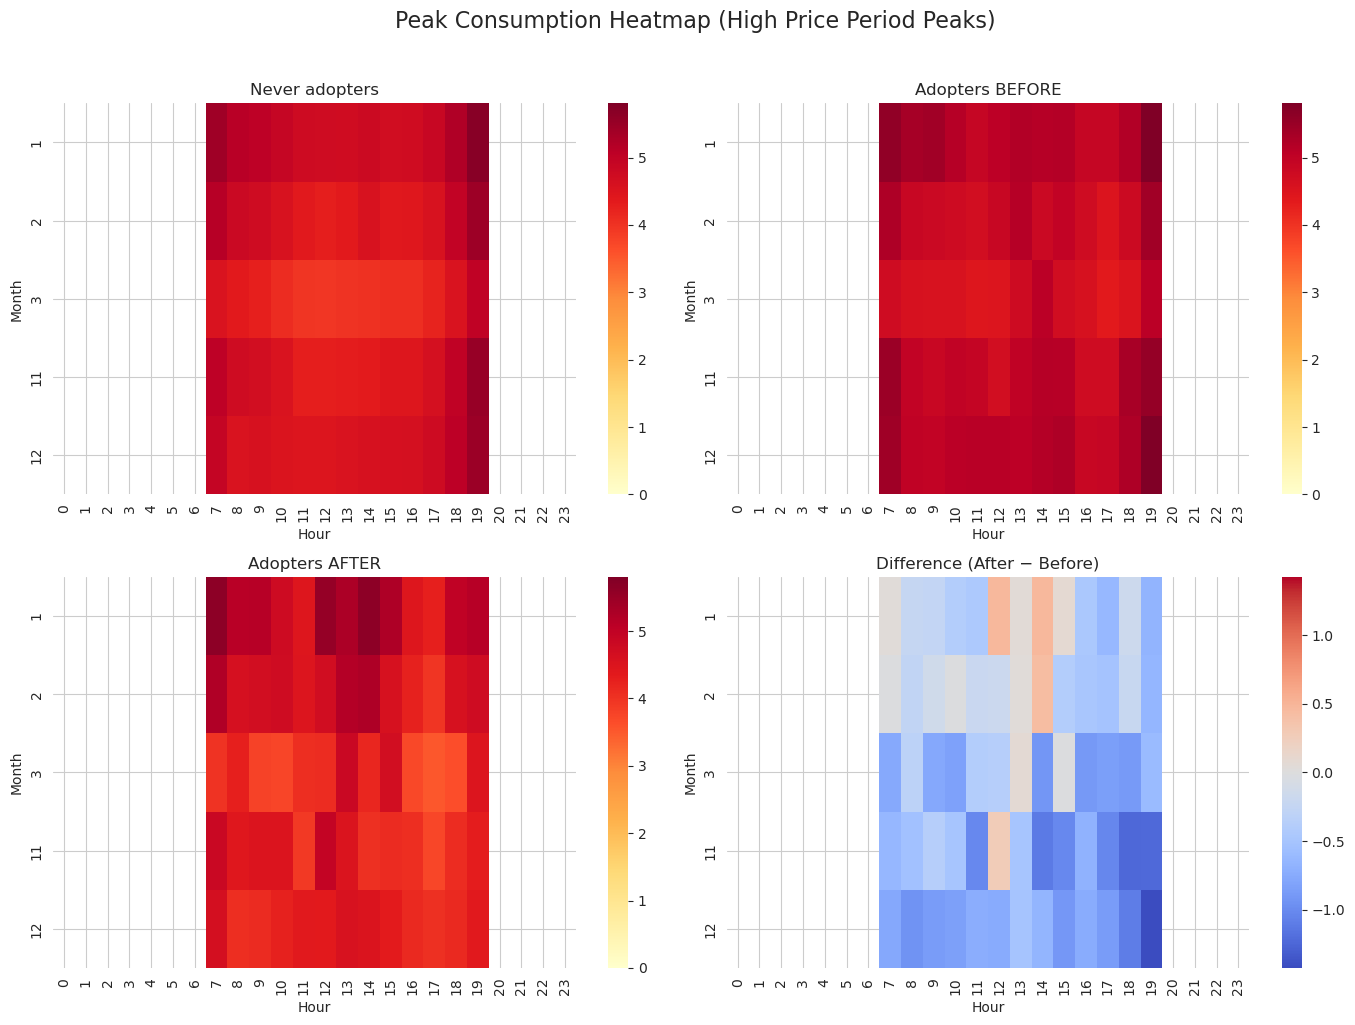

In [13]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

please upload to lakehouse

StatementMeta(, a1218c3f-f2d3-49be-8874-e8bb978f4cb6, 16, Finished, Available, Finished, False)

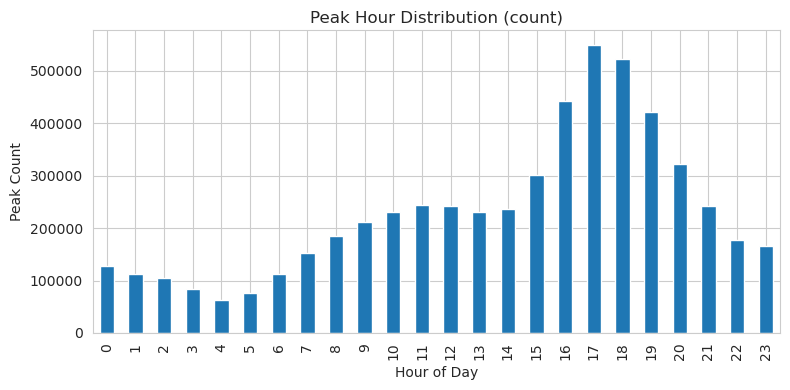

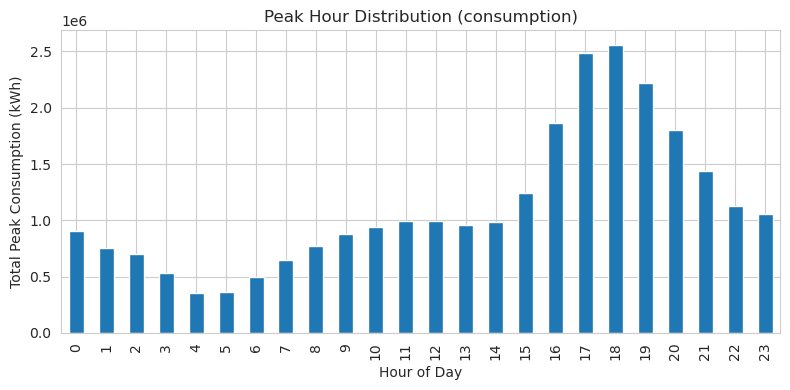

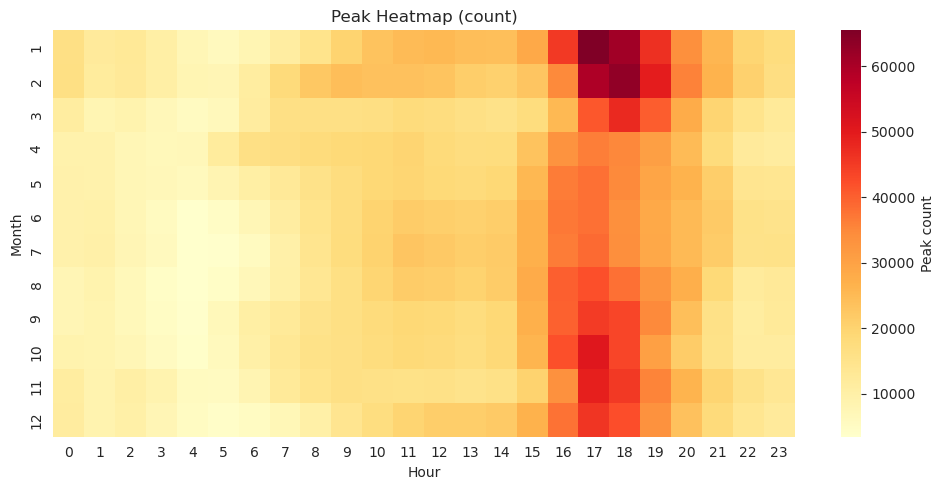

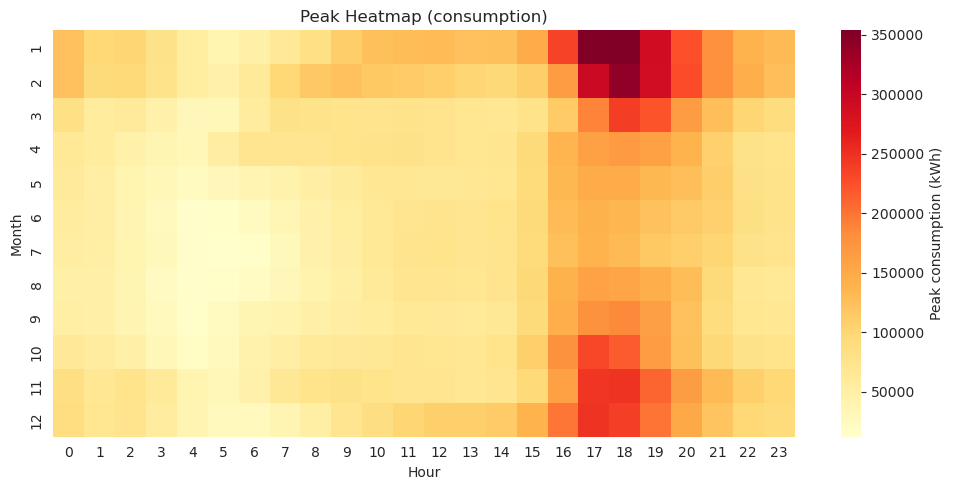

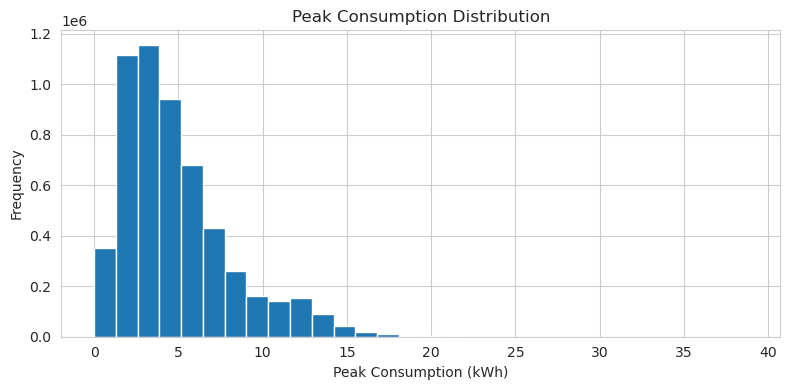

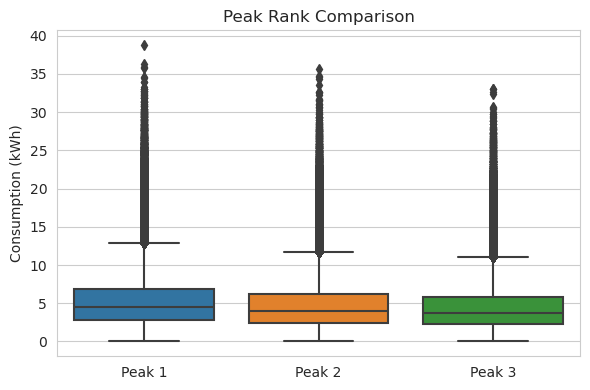

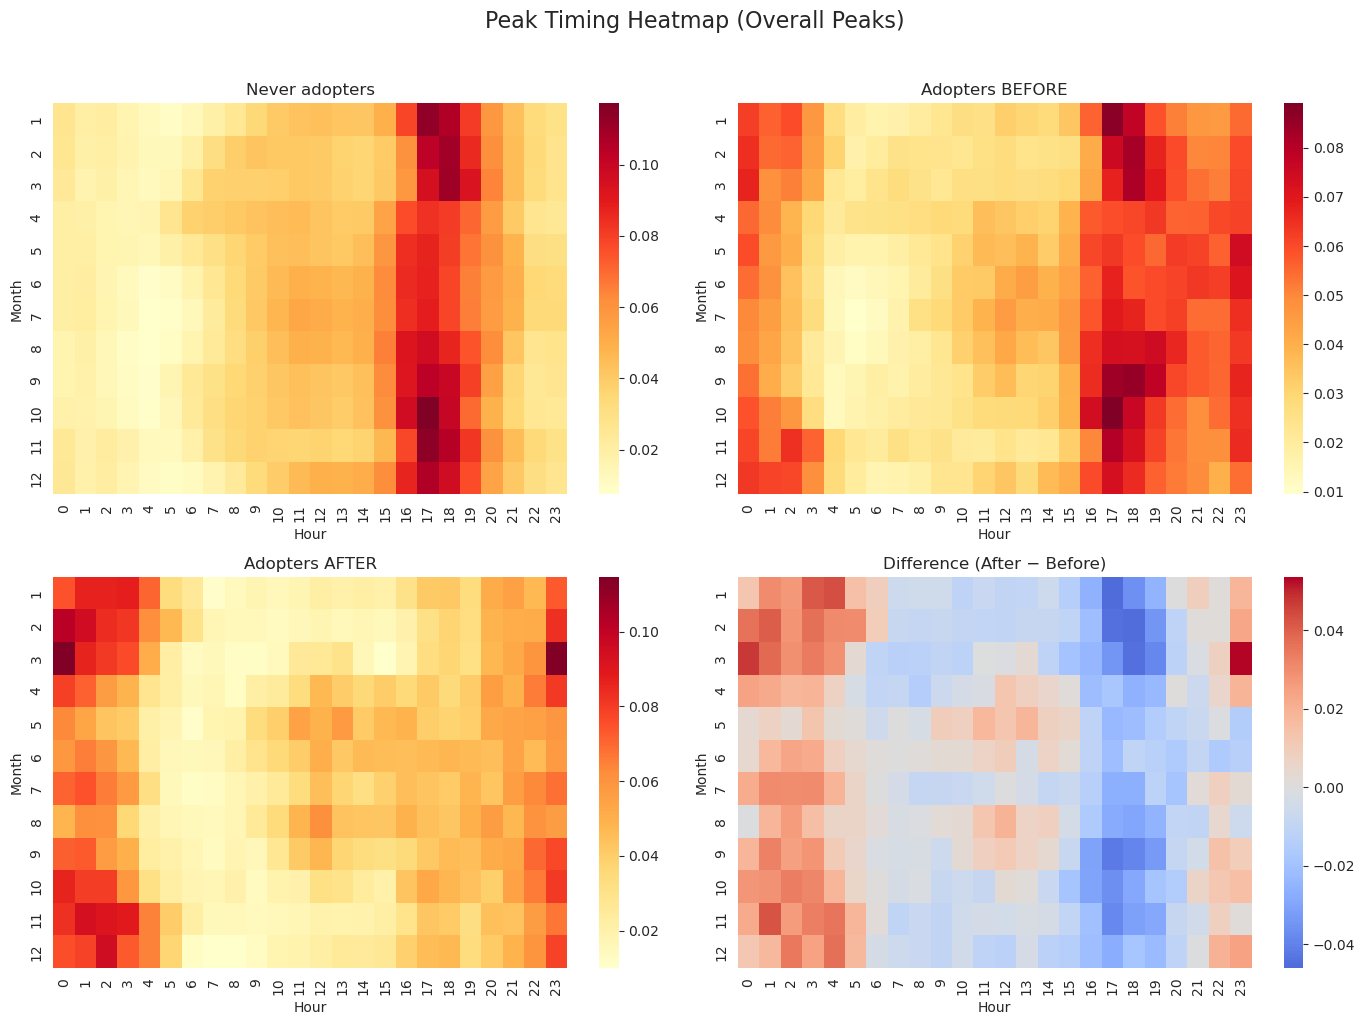

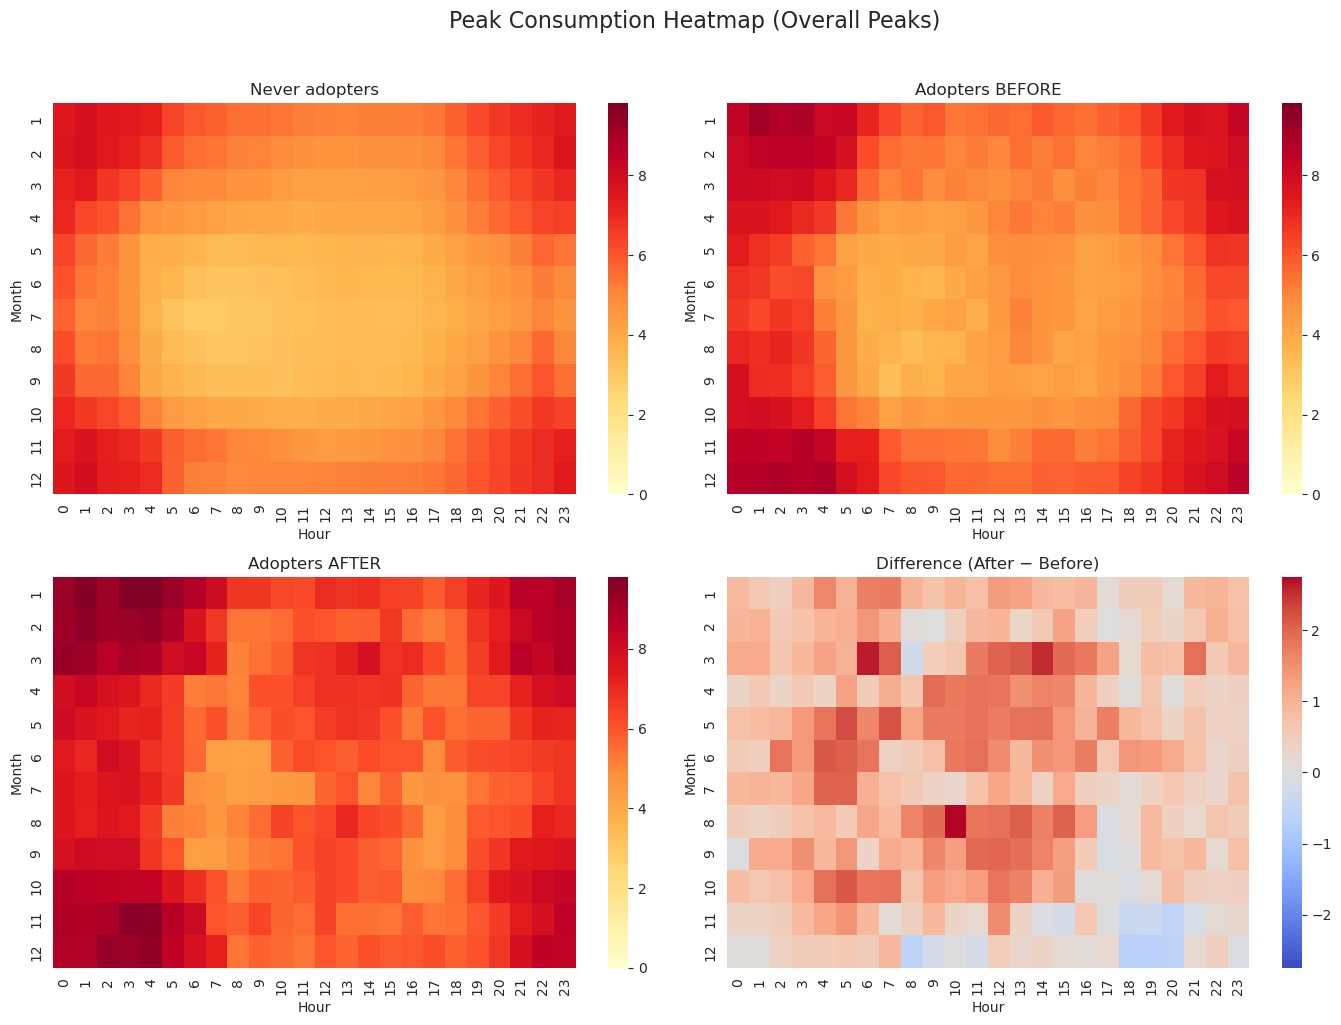

In [14]:
# Overall peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


StatementMeta(, a1218c3f-f2d3-49be-8874-e8bb978f4cb6, 17, Finished, Available, Finished, False)

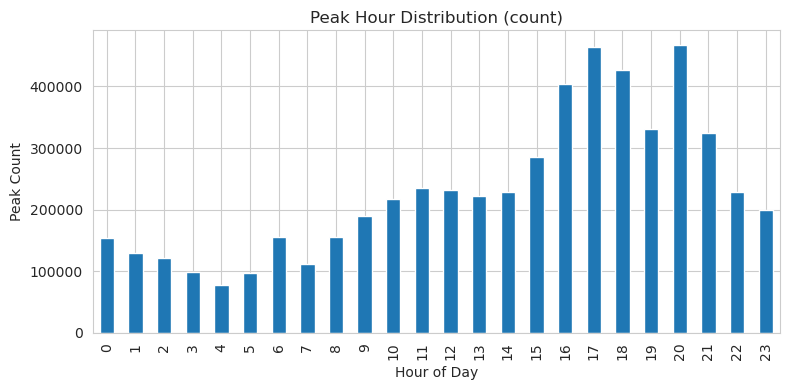

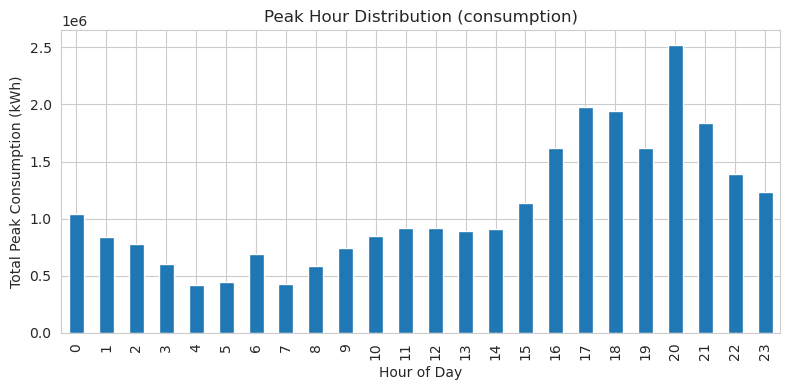

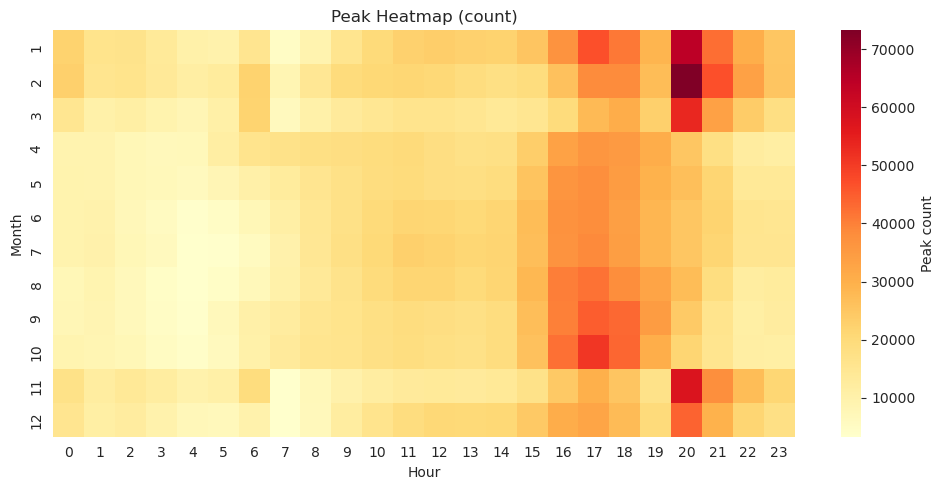

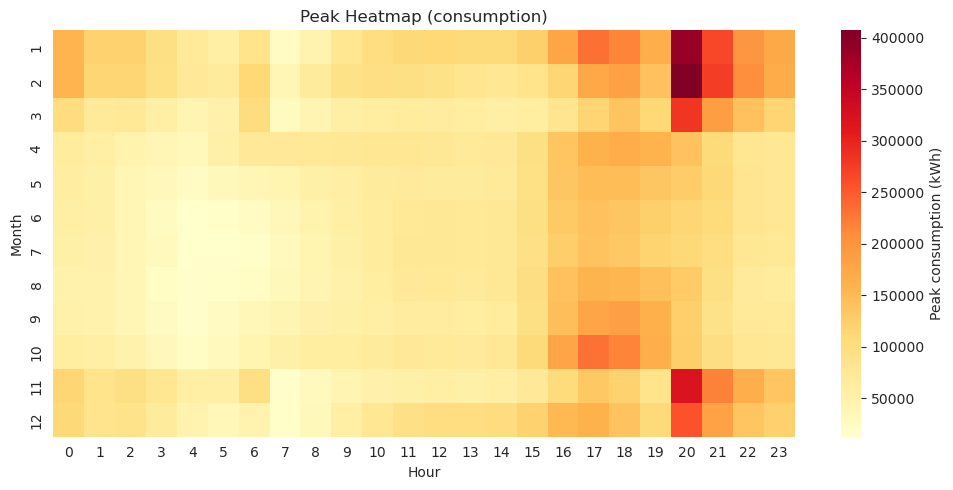

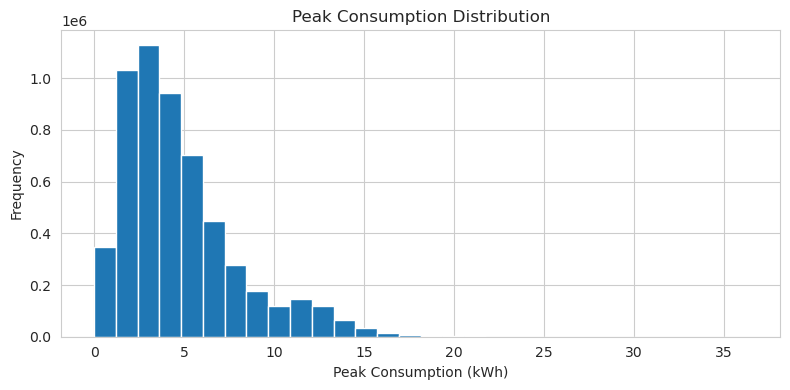

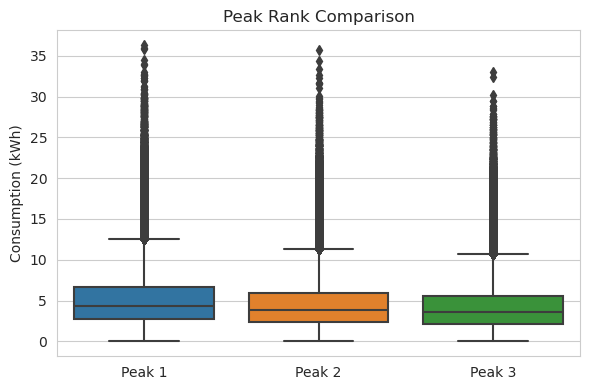

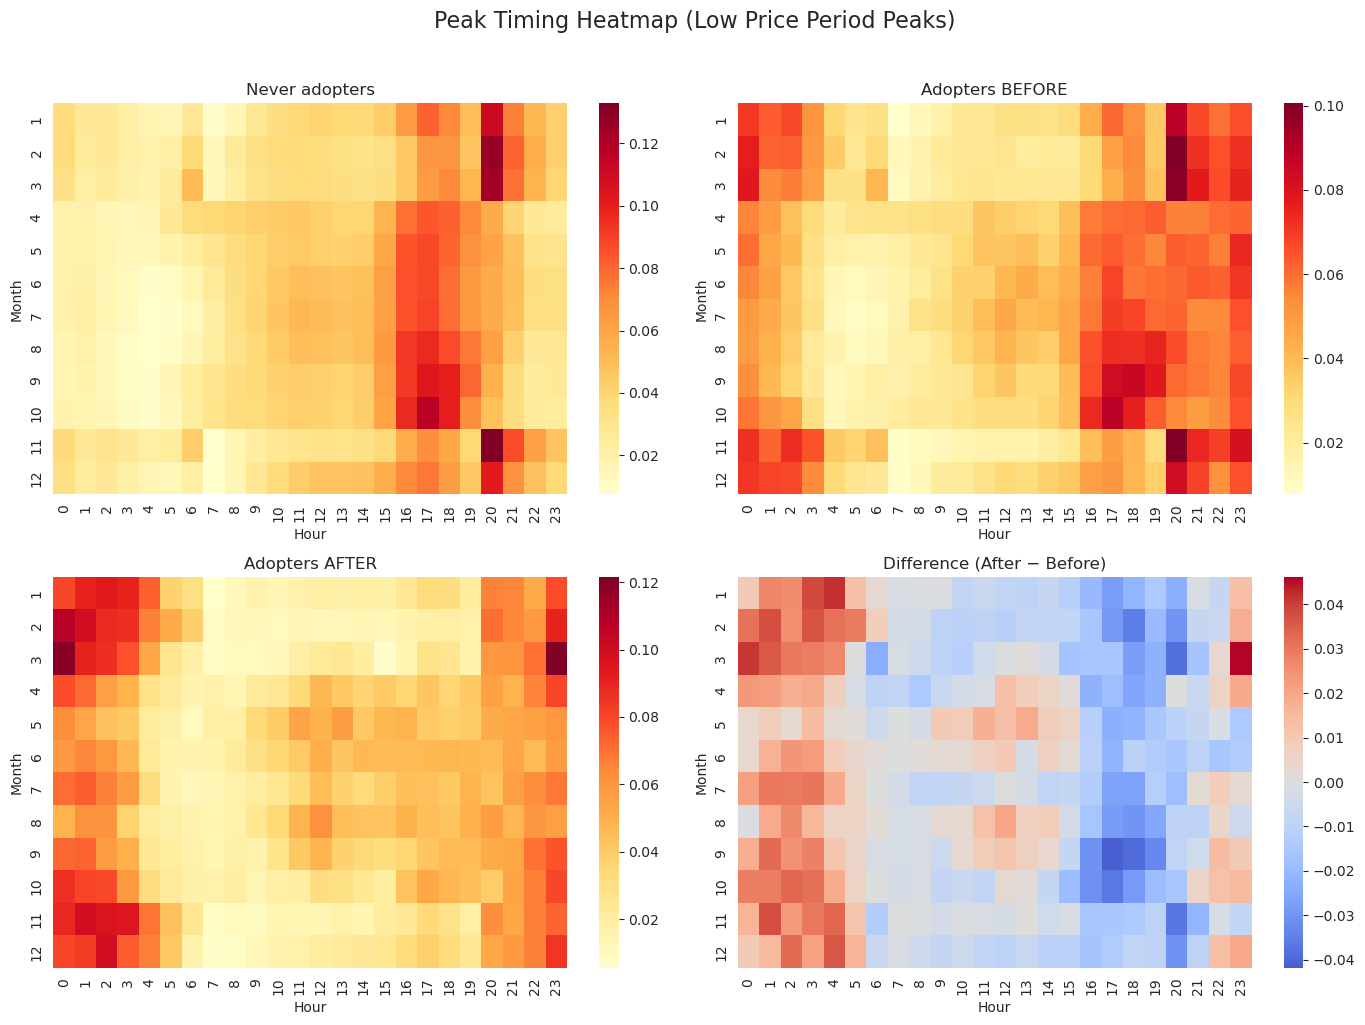

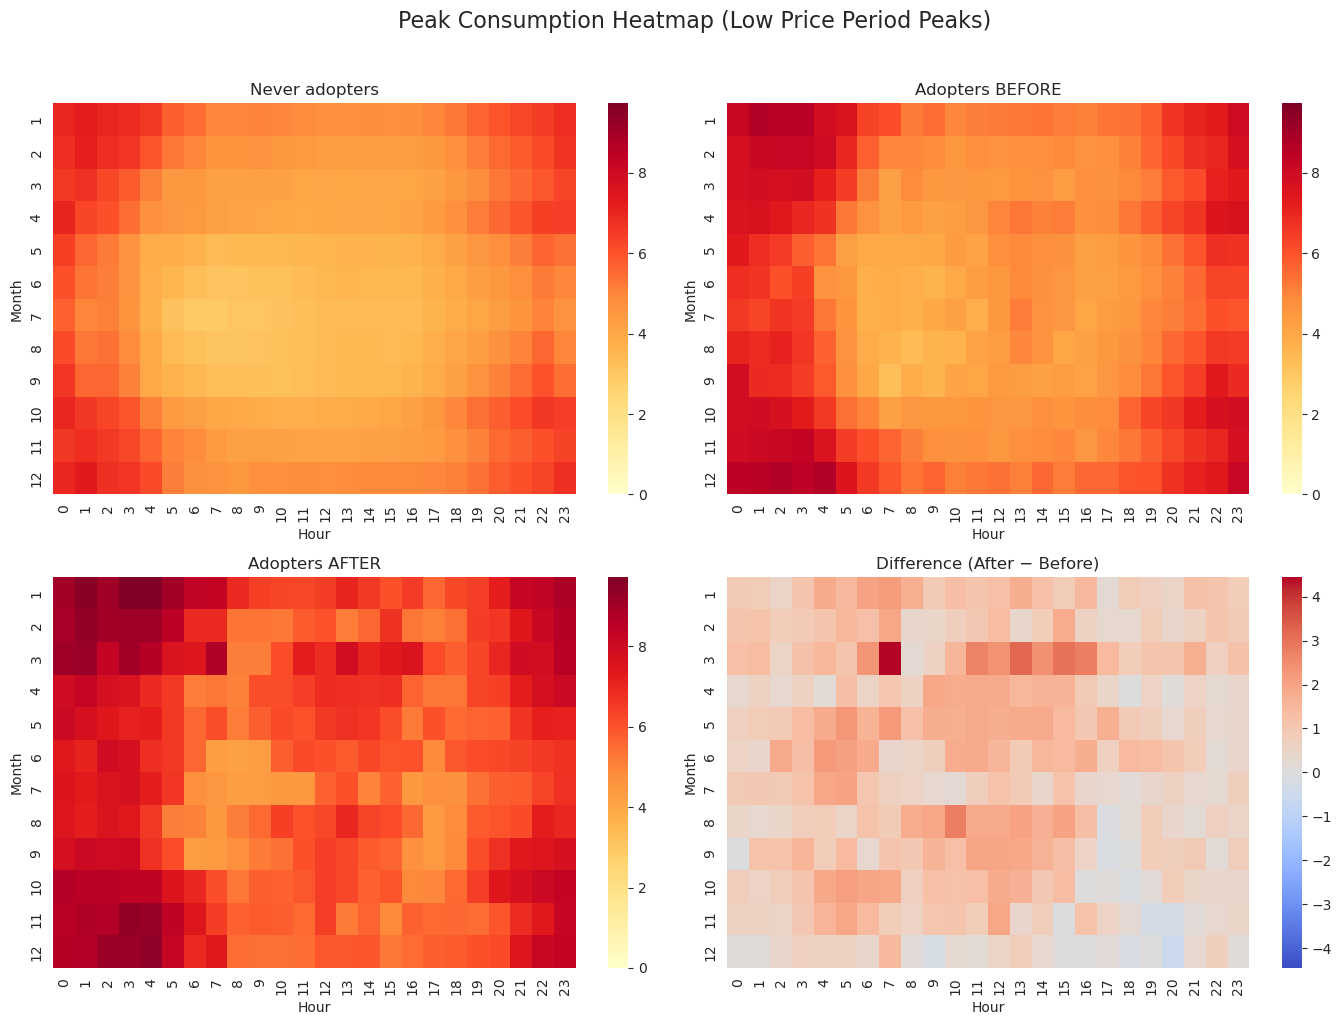

In [15]:
# Low peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)
